In [13]:
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from azure.cognitiveservices.vision.computervision.models import VisualFeatureTypes
from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time
os.environ["VISION_KEY"] = "Btkb9ZIlHLjNQo89ZLz6y4G2iiKZUZDCtHe0jmdaCg6CgSwixsZeJQQJ99CCACPV0roXJ3w3AAAFACOGyXfS"
os.environ["VISION_ENDPOINT"] = "https://aitemalab2.cognitiveservices.azure.com/"
'''
Authenticate
Authenticates your credentials and creates a client.
'''
subscription_key = os.environ["VISION_KEY"]
endpoint = os.environ["VISION_ENDPOINT"]
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
'''
END - Authenticate
'''

'\nEND - Authenticate\n'

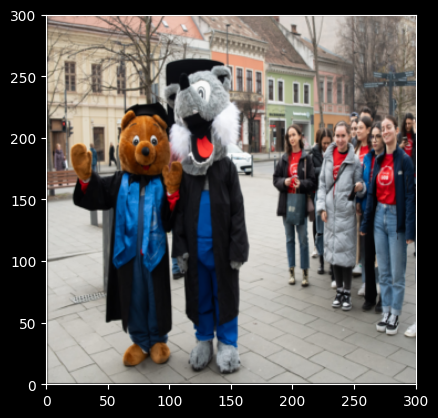

In [4]:
from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time
import matplotlib.pyplot as plt
from skimage import io
import numpy as np
im = plt.imread("data\\img.png")
fig, ax = plt.subplots()
im = ax.imshow(im, extent=[0, 300, 0, 300])
plt.show()

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import glob
import os
import numpy as np
from msrest.authentication import CognitiveServicesCredentials
from array import array
import os
from PIL import Image
import sys
import time
import matplotlib.pyplot as plt
from skimage import io
import numpy as np

def hasBike(filepath):
    with open(filepath, "rb") as img:
        result = computervision_client.analyze_image_in_stream(
            img,
            visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects]
        )
    for ob in result.objects:
        if ob.object_property == "bicycle":
            return True
    return False

def getRealLabel(filepath):
    filename = os.path.basename(filepath).lower()
    return True if filename.startswith("bike") else False

def BikeAcc(realLabels, computedLabels):
    cm = confusion_matrix(realLabels, computedLabels)
    accuracy = accuracy_score(realLabels, computedLabels)
    precision = precision_score(realLabels, computedLabels)
    recall = recall_score(realLabels, computedLabels)
    return cm, accuracy, precision, recall

def myBikeAcc(realLabels, computedLabels):
    realLabels = np.array(realLabels, dtype=int)
    computedLabels = np.array(computedLabels, dtype=int)
    TP = ((realLabels == computedLabels) & (realLabels == 1)).sum()
    TN = ((realLabels == computedLabels) & (realLabels == 0)).sum()
    FP = ((realLabels != computedLabels) & (realLabels == 0)).sum()
    FN = ((realLabels != computedLabels) & (realLabels == 1)).sum()
    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    recall_negative = TN / (TN + FN) if (TN + FN) > 0 else 0
    return accuracy, precision, recall, recall_negative

# --- Run analysis on all JPGs ---
all_files = sorted(glob.glob("data/*.jpg"))
real_labels = []
computed_labels = []

for file_path in all_files:
    real = getRealLabel(file_path)
    predicted = hasBike(file_path)
    print(f"{os.path.basename(file_path):30s}  real={real}  predicted={predicted}")
    real_labels.append(real)
    computed_labels.append(predicted)

# --- Metrics ---
cm, acc, prec, rec = BikeAcc(real_labels, computed_labels)
print("\nConfusion Matrix:\n", cm)
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")

acc2, prec2, rec2, rec_neg = myBikeAcc(real_labels, computed_labels)
print(f"\n[myBikeAcc] Accuracy={acc2:.3f}  Precision={prec2:.3f}  Recall={rec2:.3f}  Recall(neg)={rec_neg:.3f}")






animals.jpg                     real=False  predicted=False
bike02.jpg                      real=True  predicted=True
bike03.jpg                      real=True  predicted=True
bike04.jpg                      real=True  predicted=True
bike07.jpg                      real=True  predicted=True
bike08.jpg                      real=True  predicted=False
bike09 (1).jpg                  real=True  predicted=True
bike09.jpg                      real=True  predicted=True
bike1.jpg                       real=True  predicted=True
bike10.jpg                      real=True  predicted=True
traffic01.jpg                   real=False  predicted=False
traffic02.jpg                   real=False  predicted=False
traffic03.jpg                   real=False  predicted=False
traffic05.jpg                   real=False  predicted=False
traffic07.jpg                   real=False  predicted=False

Confusion Matrix:
 [[6 0]
 [1 8]]
Accuracy : 0.933
Precision: 1.000
Recall   : 0.889

[myBikeAcc] Accuracy=0.933  Pr

In [25]:
import glob
def bikeCoords(filepath):
    img = open(filepath, "rb")
    result = computervision_client.analyze_image_in_stream(img, visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects])
    for ob in result.objects:
        if ob.object_property == "bicycle":
            return ob.rectangle
def hasBike(filepath):
    with open(filepath, "rb") as img:
        result = computervision_client.analyze_image_in_stream(
            img,
            visual_features=[VisualFeatureTypes.tags, VisualFeatureTypes.objects]
        )
    for ob in result.objects:
        if ob.object_property == "bicycle":
            return True
    return False

all_files = sorted(glob.glob("data/*.jpg"))
real_labels = []
computed_labels = []
manual_annotations = {
    "data\\bike02.jpg": [(21, 94, 356, 223)],
     "data\\bike03.jpg": [(158, 145, 181, 258)],
     "data\\bike05.jpg": [(68, 50, 285, 285)],
     "data\\bike06.jpg": [(158, 145, 181, 258)],
     "data\\bike07.jpg": [(62, 205, 232, 209)],
     "data\\bike08.jpg": [(57, 2, 328, 351)],

}

for file_path in all_files:
    if(hasBike(file_path)):
        coordsToDraw = bikeCoords(file_path)
        im = plt.imread(file_path)
        fig= plt.imshow(im)
        fig.axes.add_patch(plt.Rectangle(xy=(coordsToDraw.x, coordsToDraw.y), width=coordsToDraw.w, height=coordsToDraw.h, fill=False, color="red"))
        if file_path in manual_annotations:
            for coords in manual_annotations[file_path]:
                fig.axes.add_patch(plt.Rectangle(xy=(coords[0], coords[1]), width=coords[2], height=coords[3], fill=False, color="blue"))



        plt.show()
        plt.show()



ComputerVisionErrorResponseException: (429) Requests to the Analyze Image Operation under Computer Vision API (v3.2) have exceeded call rate limit of your current ComputerVision F0 pricing tier. Please retry after 42 seconds. To increase your rate limit switch to a paid tier.

In [ ]:
# --- 2c: Evaluate AI detection performance vs manual ground truth ---

def compute_iou(boxA, boxB):
    """Compute IoU between two boxes (x, y, w, h)."""
    ax1, ay1 = boxA[0], boxA[1]
    ax2, ay2 = ax1 + boxA[2], ay1 + boxA[3]
    bx1, by1 = boxB[0], boxB[1]
    bx2, by2 = bx1 + boxB[2], by1 + boxB[3]

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    areaA = boxA[2] * boxA[3]
    areaB = boxB[2] * boxB[3]
    union_area = areaA + areaB - inter_area

    return inter_area / union_area if union_area > 0 else 0.0


def evaluate_detections(gt_boxes, pred_boxes, iou_threshold=0.5):
    """
    For one image: match predicted boxes to ground truth boxes.
    Returns TP, FP, FN and per-pair IoU values.
    """
    matched_gt = set()
    TP, FP = 0, 0
    ious = []

    for pred in pred_boxes:
        best_iou = 0
        best_idx = -1
        for i, gt in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            iou = compute_iou(pred, gt)
            if iou > best_iou:
                best_iou = iou
                best_idx = i
        if best_iou >= iou_threshold:
            TP += 1
            matched_gt.add(best_idx)
            ious.append(best_iou)
        else:
            FP += 1

    FN = len(gt_boxes) - len(matched_gt)
    return TP, FP, FN, ious


# --- Run evaluation over all annotated images ---
IOU_THRESHOLD = 0.5
total_TP, total_FP, total_FN = 0, 0, 0
all_ious = []

print(f"{'Image':<20} {'GT boxes':<10} {'Pred boxes':<12} {'TP':<5} {'FP':<5} {'FN':<5} {'Mean IoU'}")
print("-" * 70)

for fname, gt_boxes in manual_annotations.items():
    file_path = os.path.join(DATA_DIR, fname)

    # Get AI-predicted boxes
    pred_rects = bikeCoords(file_path)  # returns list of Azure rectangles
    pred_boxes = [(r.x, r.y, r.w, r.h) for r in pred_rects] if pred_rects else []

    TP, FP, FN, ious = evaluate_detections(gt_boxes, pred_boxes, IOU_THRESHOLD)
    mean_iou = np.mean(ious) if ious else 0.0

    total_TP += TP
    total_FP += FP
    total_FN += FN
    all_ious.extend(ious)

    print(f"{fname:<20} {len(gt_boxes):<10} {len(pred_boxes):<12} {TP:<5} {FP:<5} {FN:<5} {mean_iou:.3f}")

# --- Overall metrics ---
precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0
recall    = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0
mean_iou_all = np.mean(all_ious) if all_ious else 0.0

print("\n=== Overall Detection Performance ===")
print(f"IoU Threshold : {IOU_THRESHOLD}")
print(f"Mean IoU      : {mean_iou_all:.3f}  (how well boxes overlap on average)")
print(f"Precision     : {precision:.3f}      (of all predicted boxes, how many were correct)")
print(f"Recall        : {recall:.3f}      (of all real bikes, how many were found)")